In [28]:
import arviz.preview as az
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from xarray import open_datatree

jax.config.update("jax_enable_x64", True)

## RDM

In [118]:
RESULTS_PATH = "../outputs/rdm/model.num_bins=12/model.num_mid=128/optimizer=adam_cosine_decay/train_steps=500000/parameter_recovery_approx.nc"
dt = open_datatree(RESULTS_PATH)
dt.groups, dt.param_names

(('/', '/posterior', '/observed_data', '/constant_data', '/prior'),
 ['v_intercept', 'v_slope', 's_true', 'b', 't0'])

In [ ]:
def fix_chain_draw_dims(dt):
    """Swap chain and draw dimensions in the posterior group.

    Needed for files saved before the axis-ordering bug was fixed in
    parameter_recovery.py (lax.scan puts draws first, so the saved
    posterior had chain↔draw swapped).
    """
    import xarray as xr

    posterior_fixed = dt.posterior.dataset.rename({"chain": "draw", "draw": "chain"})
    dt_new =  xr.DataTree.from_dict({
        "/posterior":     posterior_fixed,
        "/observed_data": dt.observed_data.dataset,
        "/constant_data": dt.constant_data.dataset,
        "/prior":         dt.prior.dataset,
    })
    dt_new.attrs["param_names"] = dt.param_names
    return dt_new

dt = fix_chain_draw_dims(dt)

### Parameter Summary

In [51]:
summary = az.summary(dt)
summary

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
v_intercept[0],0.92,0.14,0.69,1.14,2146.55,2344.18,1.00,0.00,0.0
v_intercept[1],0.43,0.05,0.34,0.51,1417.37,1554.79,1.00,0.00,0.0
v_intercept[2],0.98,0.20,0.67,1.31,1488.79,1630.14,1.00,0.01,0.0
v_intercept[3],1.09,0.17,0.82,1.36,2218.20,2069.98,1.00,0.00,0.0
v_intercept[4],0.79,0.13,0.59,1.00,1969.96,2072.94,1.00,0.00,0.0
...,...,...,...,...,...,...,...,...,...
t0[45],0.02,0.01,0.01,0.03,1123.76,1221.57,1.00,0.00,0.0
t0[46],0.62,0.01,0.61,0.63,1981.12,1959.18,1.00,0.00,0.0
t0[47],0.43,0.01,0.40,0.45,2066.71,1931.69,1.00,0.00,0.0
t0[48],0.03,0.00,0.03,0.03,356.22,413.03,1.01,0.00,0.0


### Convergence Diagnostics

In [33]:
(summary["r_hat"] > 1.01).sum()

np.int64(5)

In [34]:
(summary["r_hat"] > 1.05).sum()

np.int64(4)

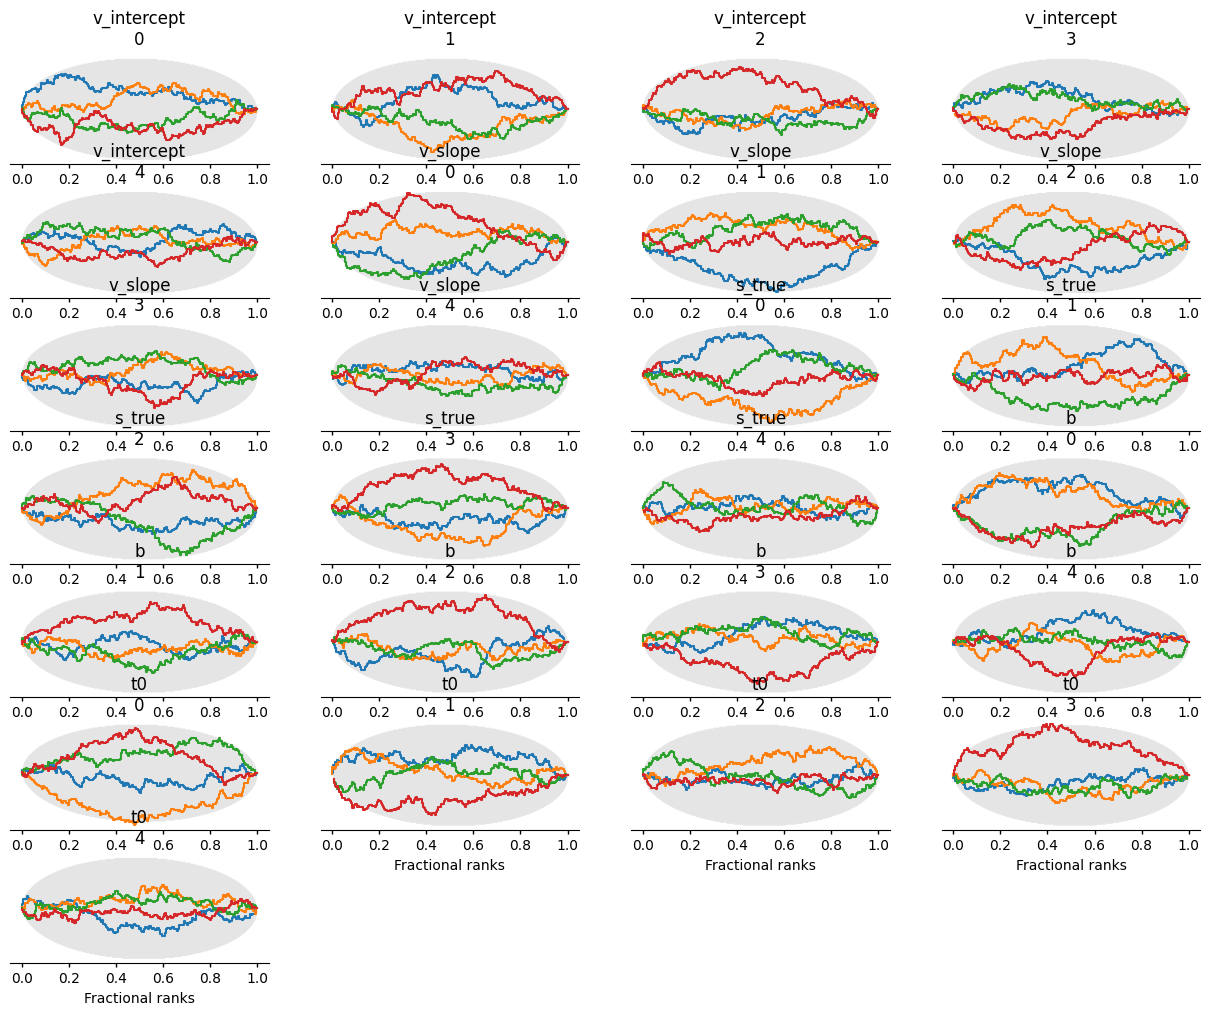

In [39]:
fig = az.plot_rank(dt, coords={"subject": np.arange(5)});

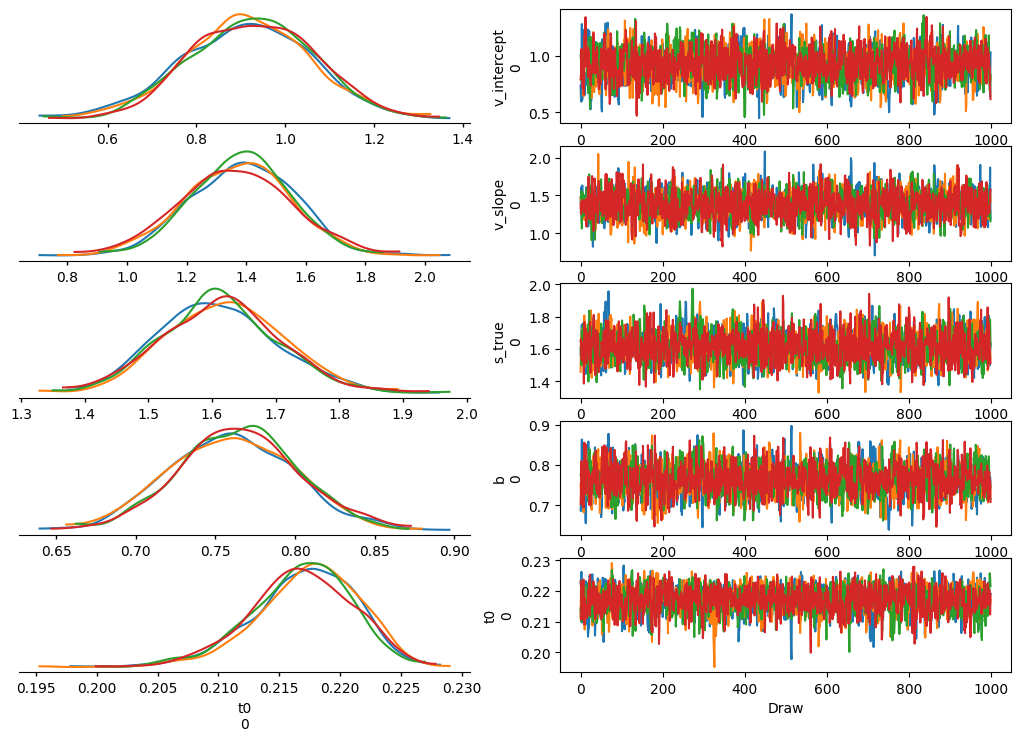

In [42]:
fig = az.plot_trace_dist(dt, coords={"subject": np.arange(1)}, compact=False);

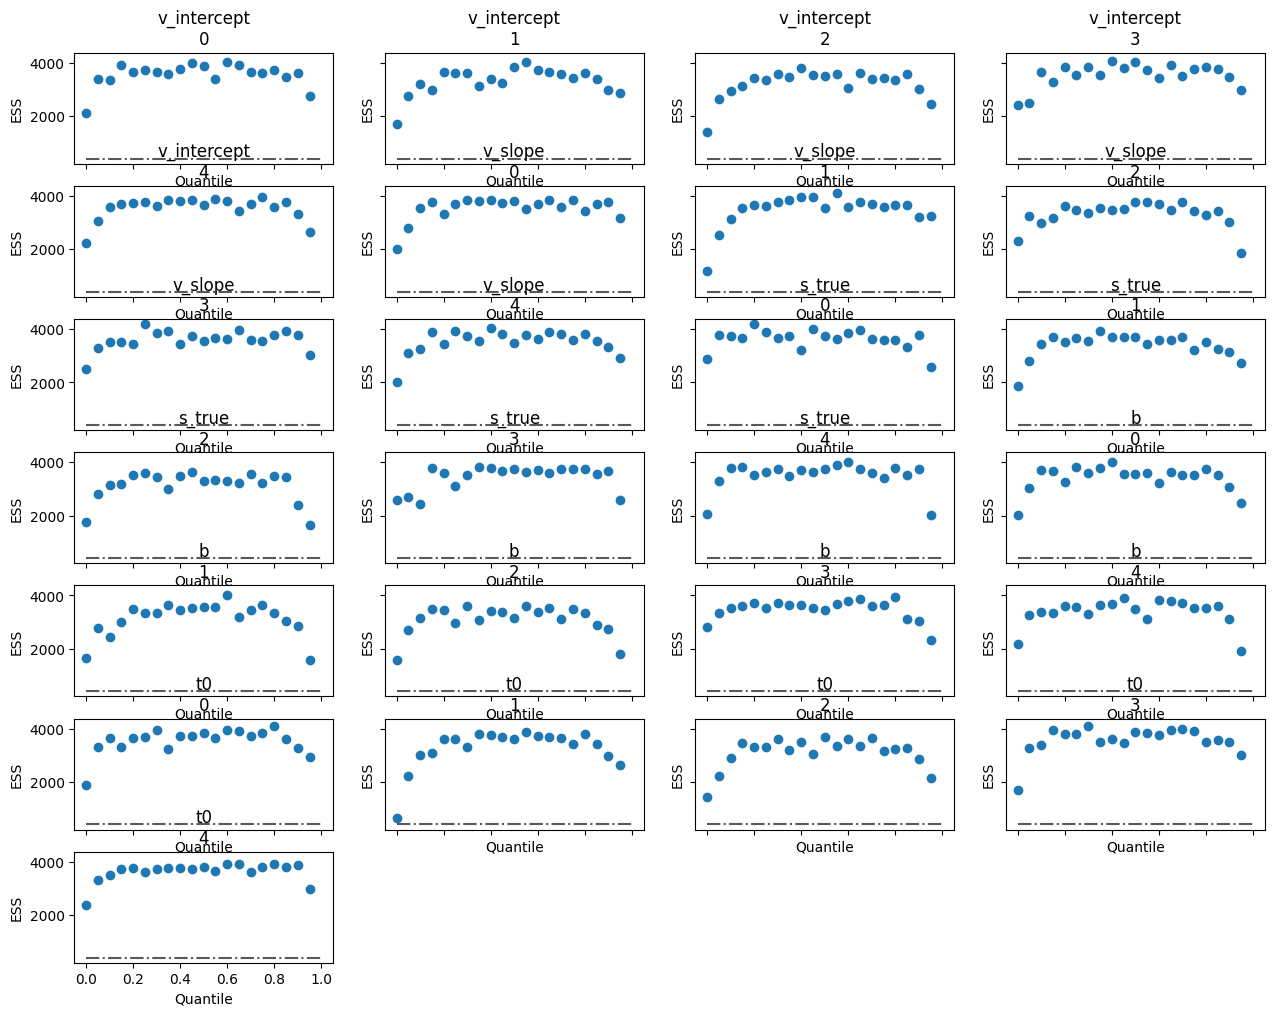

In [43]:
az.plot_ess(dt, coords={"subject": np.arange(5)});

### Parameter Recovery

In [ ]:
def plot_parameter_recovery(dt):
    param_names = dt.param_names

    fig, axarr = plt.subplots(1, len(param_names), figsize=(3 * len(param_names), 3))

    for ax, var in zip(axarr, param_names):
        posterior_mean = dt.posterior[var].mean(dim=["chain", "draw"]).values
        posterior_sd = dt.posterior[var].std(dim=["chain", "draw"]).values
        true_value = dt.constant_data.theta.sel(param=var)
        ax.errorbar(true_value, posterior_mean, yerr=posterior_sd, fmt='o', alpha=0.7, capsize=3)
        lims = [min(true_value.min(), posterior_mean.min()), max(true_value.max(), posterior_mean.max())]
        ax.plot(lims, lims, 'k--', lw=1)
        r, _ = stats.pearsonr(true_value, posterior_mean)
        ax.set(title=f"{var} - r = {r:.2f}", xlabel="True", ylabel="Posterior mean ± SD")

    plt.tight_layout()

    return fig, axarr

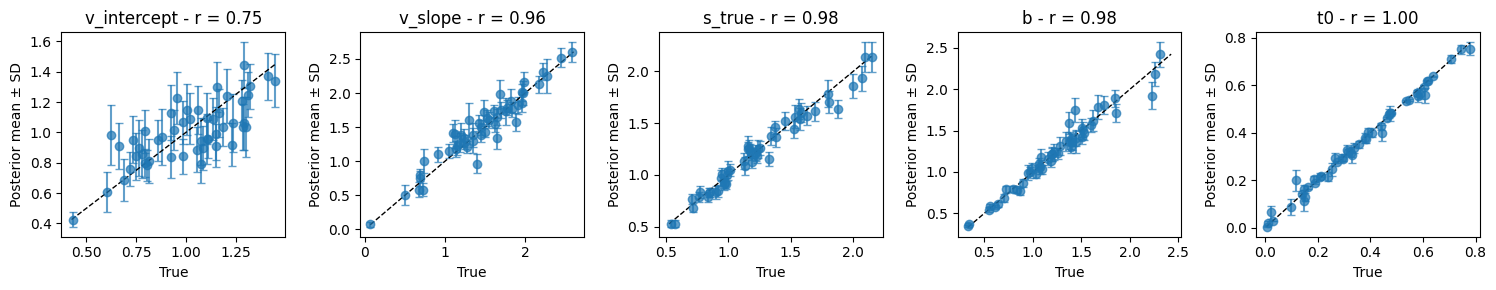

In [53]:
plot_parameter_recovery(dt);

### Posterior Contraction

In [62]:
def calc_posterior_contraction(dt, param_name):
    posterior_var = dt.posterior[param_name].var(dim=["chain", "draw"]).values
    prior_var = dt.prior[param_name].var(dim=["draw"]).values
    return np.clip(1.0 - (posterior_var / prior_var), 0, 1)

In [63]:
def plot_posterior_contraction(dt):
    param_names = dt.param_names

    fig, axarr = plt.subplots(1, len(param_names), figsize=(3 * len(param_names), 3))

    for ax, var in zip(axarr, param_names):
        posterior_contraction = calc_posterior_contraction(dt, var)
        true_value = dt.constant_data.theta.sel(param=var)
        ax.plot(true_value, posterior_contraction, "o")
        ax.ticklabel_format(useOffset=False)
        ax.set(title=var, xlabel="True parameter value", ylabel="Posterior contraction")

    plt.tight_layout()

    return fig, axarr

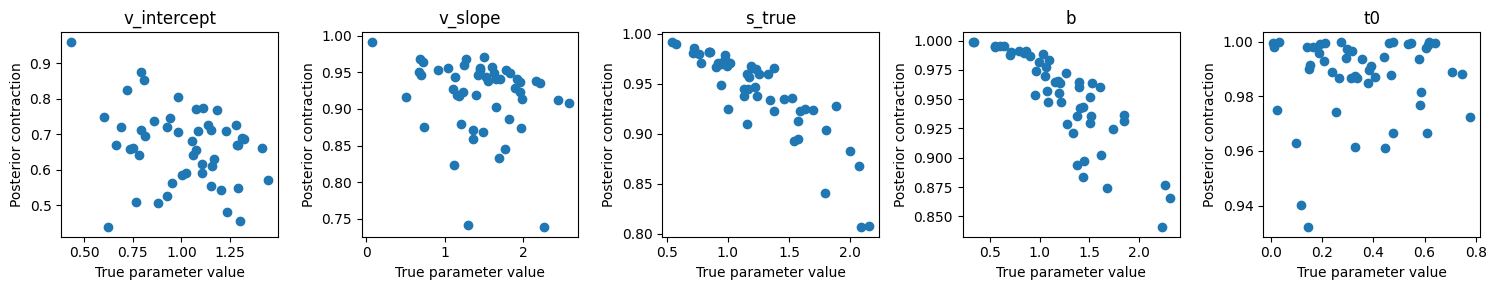

In [64]:
plot_posterior_contraction(dt);

### Prior Samples

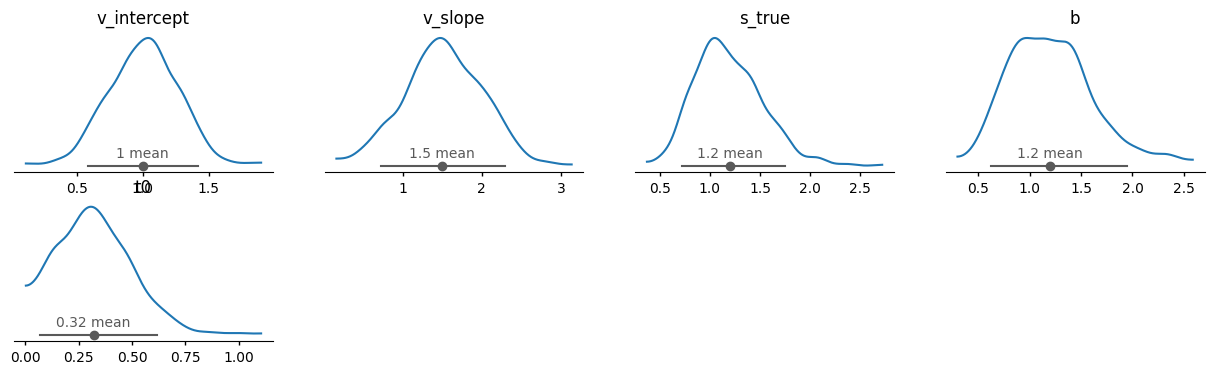

In [65]:
az.plot_dist(dt, group="prior");

### Data

In [60]:
def plot_data_hist(dt):
    subject_idx = np.clip(dt.observed_data.subject.values, 0, 20)
    num_subjects = len(subject_idx)
    fig, axarr = plt.subplots(2, num_subjects // 2, figsize=(2 * num_subjects, 6))
    if num_subjects == 1:
        axarr = [axarr]

    for posterior_sd in range(num_subjects):
        ax = axarr.flatten()[posterior_sd]
        rt = dt.observed_data.rt[posterior_sd]
        choice = dt.observed_data.choice[posterior_sd]
        ax.hist(rt[choice == 1], bins=20, color="darkgreen", alpha=0.5, label="correct")
        ax.hist(rt[choice == 0], bins=20, color="indianred", alpha=0.5, label="error")
        ax.set_title(f"Subject {posterior_sd}; Acc = {float(np.round(np.mean(choice), 2))}")
        ax.set_xlabel("RT")
        if posterior_sd == 0:
            ax.legend()

    fig.tight_layout()

    return fig, axarr

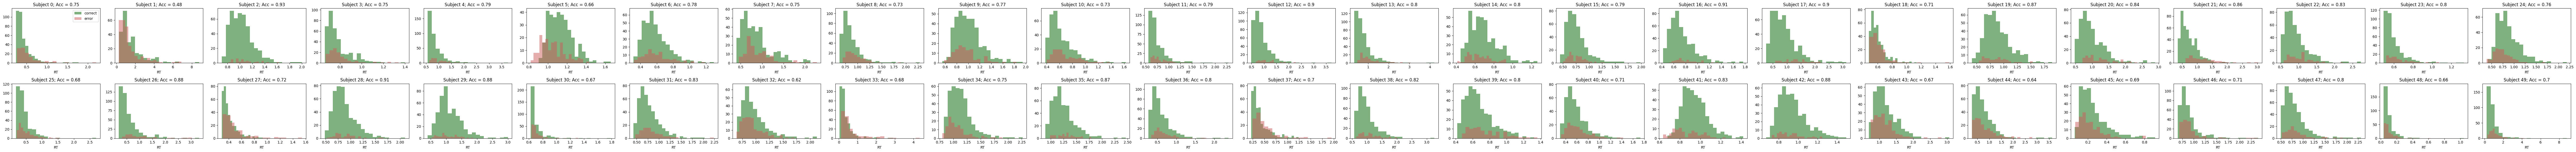

In [61]:
plot_data_hist(dt);

## Neural vs. Analytical

In [123]:
RESULTS_PATH = "../outputs/rdm/model.num_bins=12/model.num_mid=128/optimizer=adam_cosine_decay/train_steps=500000/parameter_recovery_ref.nc"
dt_ref = open_datatree(RESULTS_PATH)
dt_ref = fix_chain_draw_dims(dt_ref)

In [124]:
def plot_parameter_cross_recovery(dt, dt_ref):
    assert np.all(dt.param_names == dt_ref.param_names)

    param_names = dt.param_names

    fig, axarr = plt.subplots(1, len(param_names), figsize=(3 * len(param_names), 3))

    for ax, var in zip(axarr, param_names):
        posterior_mean = dt.posterior[var].mean(dim=["chain", "draw"]).values
        posterior_sd = dt.posterior[var].std(dim=["chain", "draw"]).values
        posterior_mean_ref = dt_ref.posterior[var].mean(dim=["chain", "draw"]).values
        posterior_sd_ref = dt_ref.posterior[var].std(dim=["chain", "draw"]).values
        ax.errorbar(posterior_mean_ref, posterior_mean, xerr=posterior_sd_ref, yerr=posterior_sd, fmt='o', alpha=0.7, capsize=3)
        lims = [min(posterior_mean_ref.min(), posterior_mean.min()), max(posterior_mean_ref.max(), posterior_mean.max())]
        ax.plot(lims, lims, 'k--', lw=1)
        r, _ = stats.pearsonr(posterior_mean_ref, posterior_mean)
        ax.set(title=f"{var} - r = {r:.2f}", xlabel="Posterior mean ± SD (reference)", ylabel="Posterior mean ± SD")

    plt.tight_layout()

    return fig, axarr

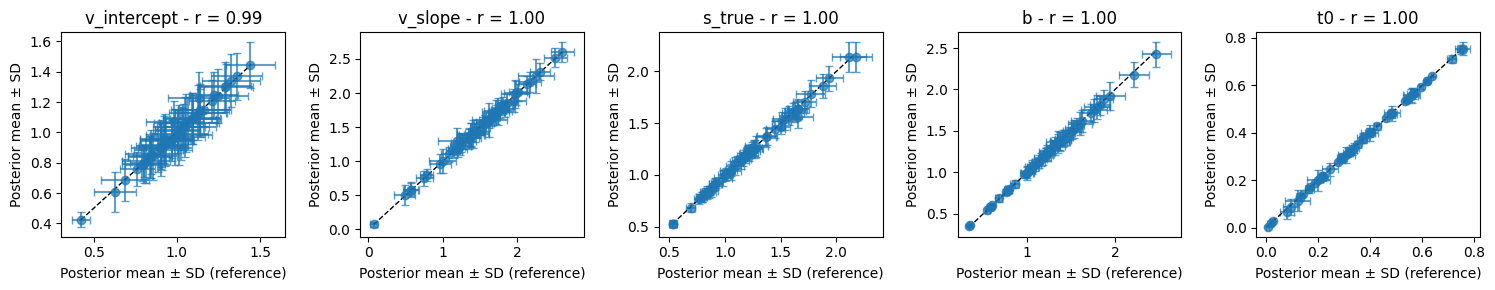

In [125]:
plot_parameter_cross_recovery(dt, dt_ref);

## CRDM (high error)

In [70]:
RESULTS_PATH = "../outputs/crdm/model.num_bins=12/model.num_mid=128/model.recovery_prior.v_c_slope_loc=2.5/model.sampler.dt=0.0005/optimizer=adam_cosine_decay/train_steps=1000000/parameter_recovery_approx.nc"
dt = open_datatree(RESULTS_PATH)
dt.groups, dt.param_names

(('/', '/posterior', '/observed_data', '/constant_data', '/prior'),
 ['v_c_intercept', 'v_c_slope', 'amp', 'tau', 's_true', 'b', 't0'])

In [71]:
dt = fix_chain_draw_dims(dt)

### Parameter Summary

In [72]:
summary = az.summary(dt)
summary

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
v_c_intercept[0],1.30,0.21,0.95,1.63,2562.96,2379.75,1.00,0.00,0.0
v_c_intercept[1],0.99,0.20,0.68,1.31,2072.39,2133.65,1.00,0.00,0.0
v_c_intercept[2],1.02,0.21,0.70,1.36,1956.62,1951.01,1.00,0.00,0.0
v_c_intercept[3],0.86,0.18,0.58,1.17,1921.67,1949.78,1.00,0.00,0.0
v_c_intercept[4],0.99,0.18,0.70,1.29,1149.49,1207.07,1.01,0.01,0.0
...,...,...,...,...,...,...,...,...,...
t0[45],0.46,0.01,0.44,0.47,2266.36,2412.16,1.00,0.00,0.0
t0[46],0.06,0.00,0.05,0.06,2166.14,2168.36,1.00,0.00,0.0
t0[47],0.41,0.00,0.41,0.41,1000.14,553.22,1.00,0.00,0.0
t0[48],0.61,0.02,0.58,0.63,984.42,1295.16,1.00,0.00,0.0


### Convergence Diagnostics

In [73]:
(summary["r_hat"] > 1.01).sum()

np.int64(9)

In [74]:
(summary["r_hat"] > 1.05).sum()

np.int64(2)

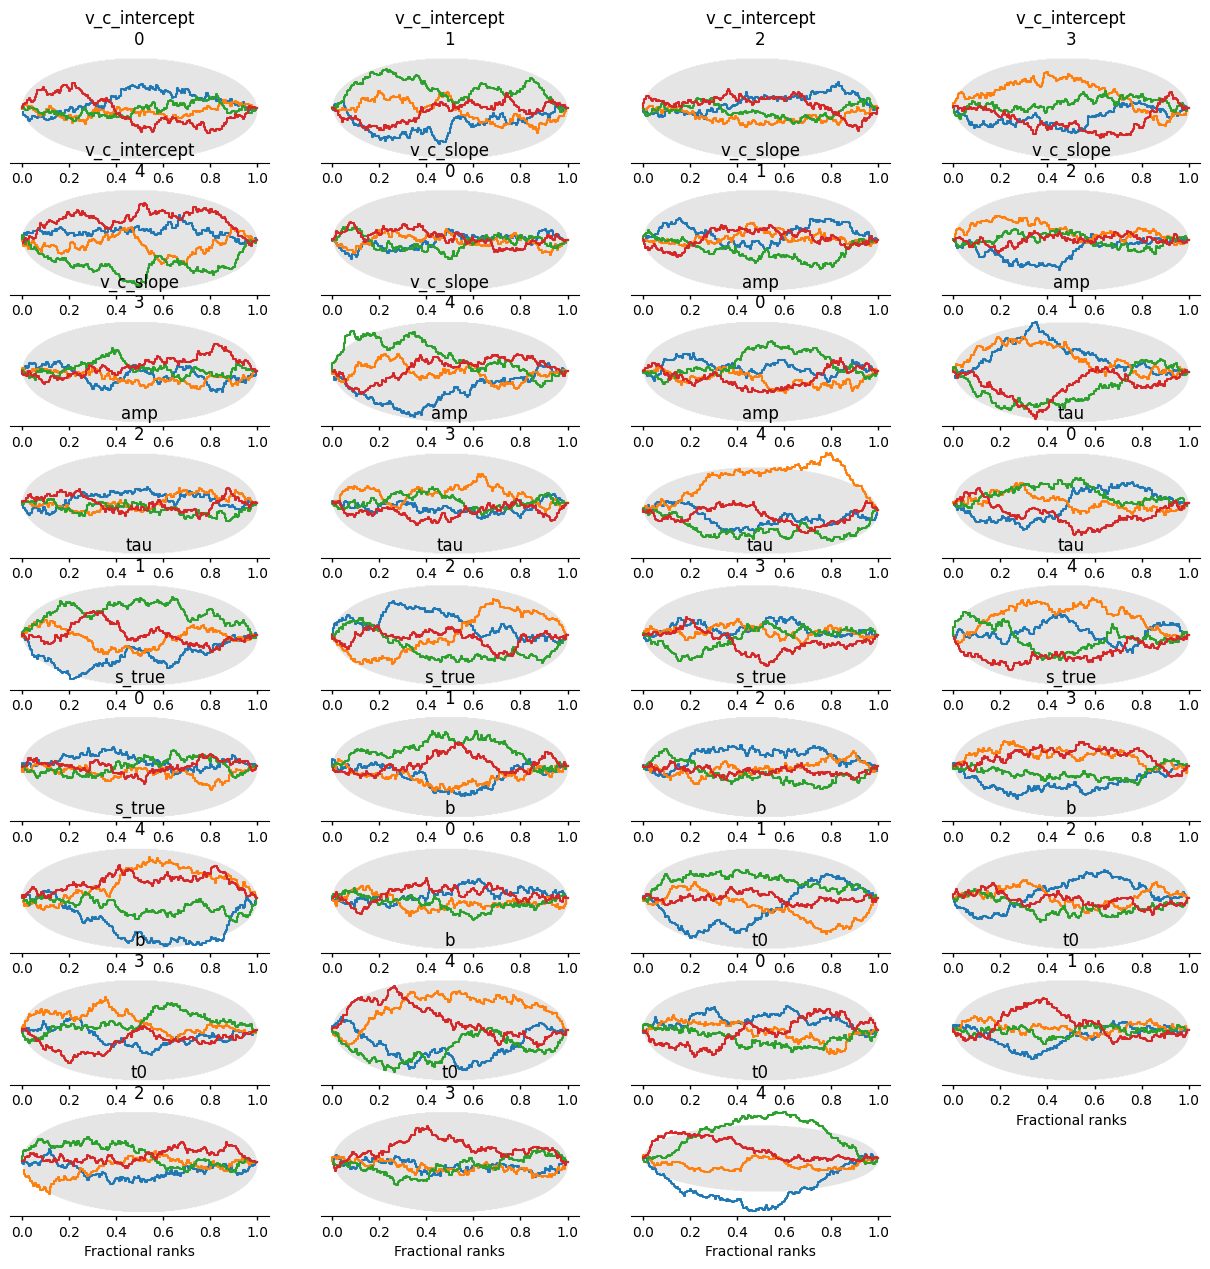

In [75]:
fig = az.plot_rank(dt, coords={"subject": np.arange(5)});

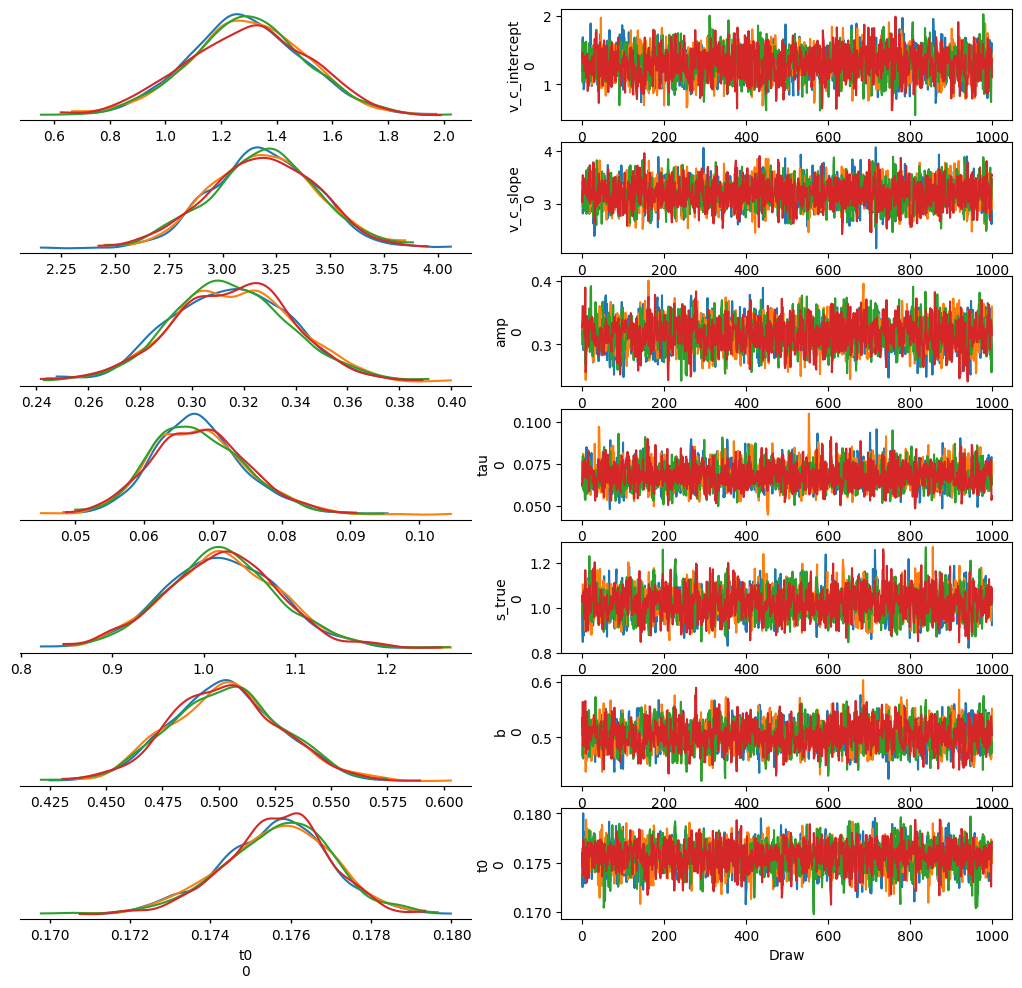

In [76]:
fig = az.plot_trace_dist(dt, coords={"subject": np.arange(1)}, compact=False);

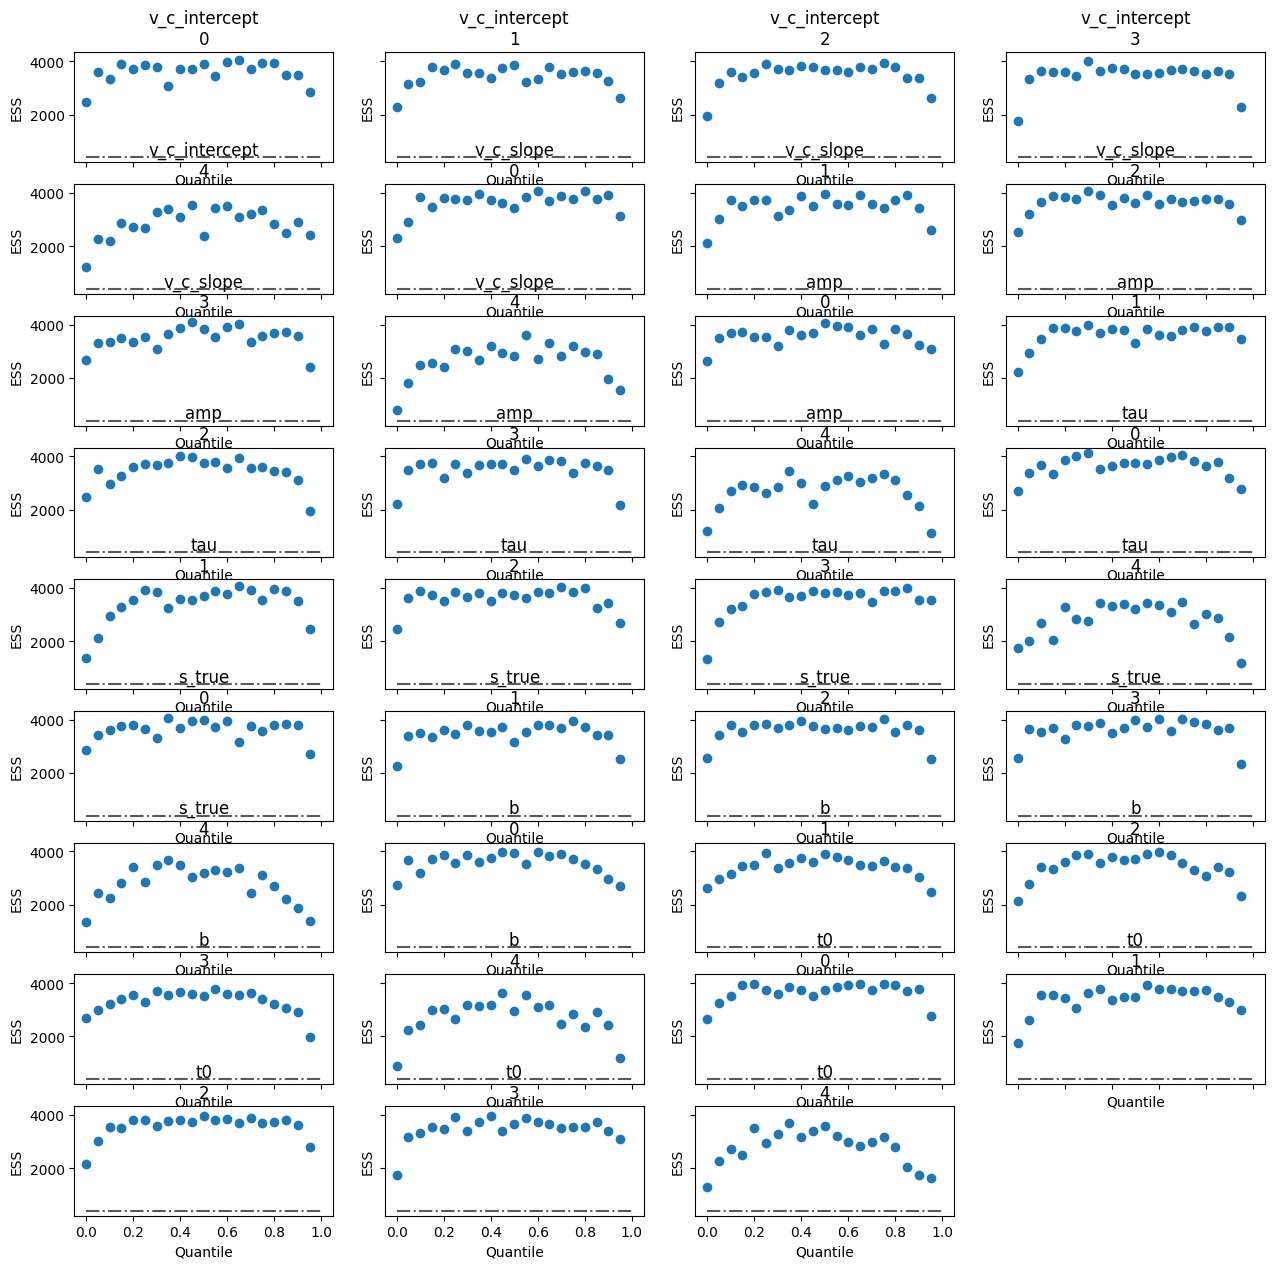

In [77]:
az.plot_ess(dt, coords={"subject": np.arange(5)});

### Parameter Recovery

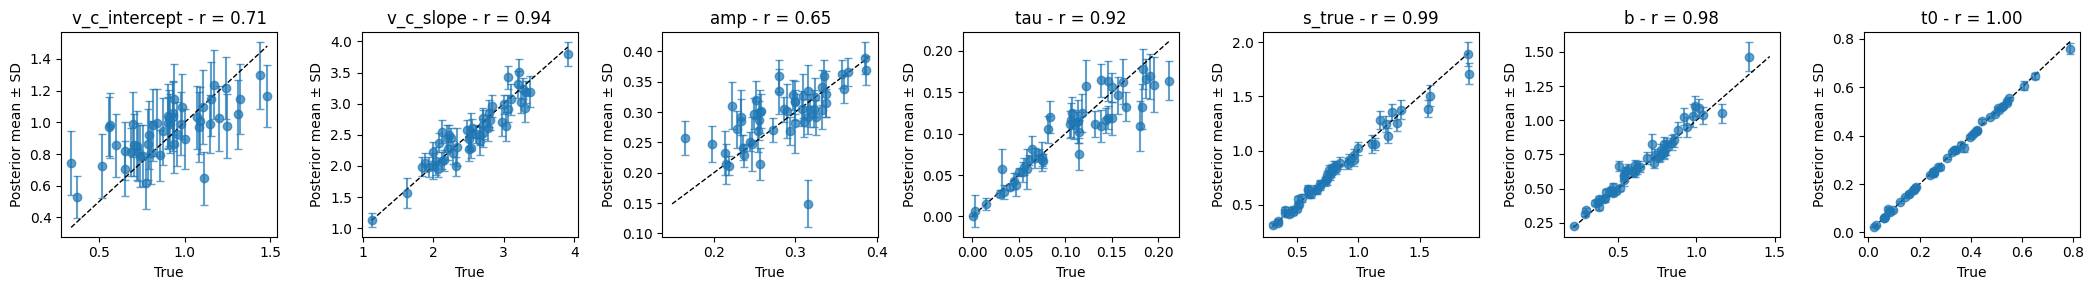

In [79]:
plot_parameter_recovery(dt);

### Posterior Contraction

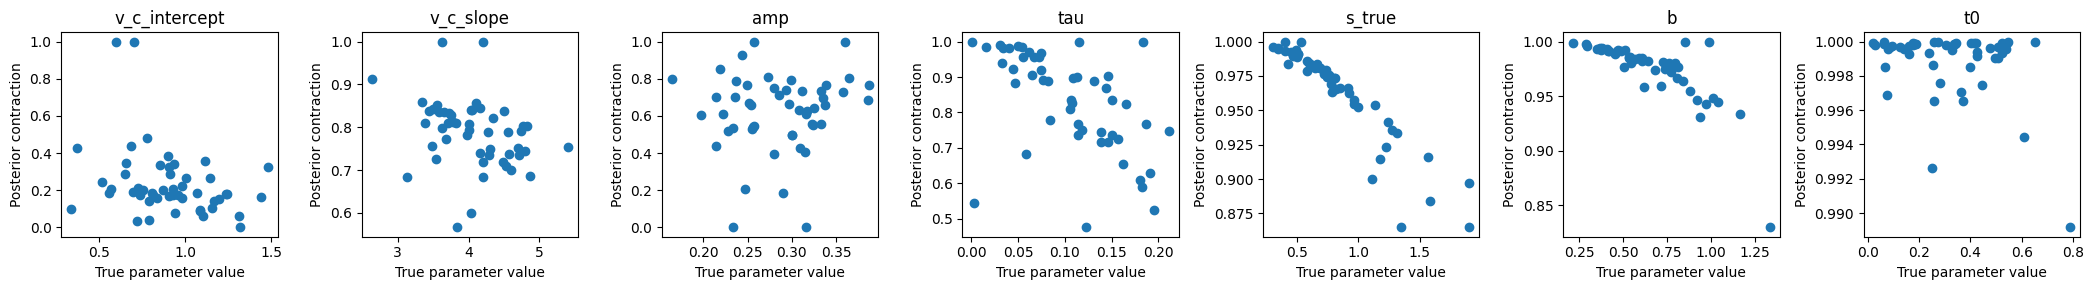

In [102]:
plot_posterior_contraction(dt);

### Prior Samples

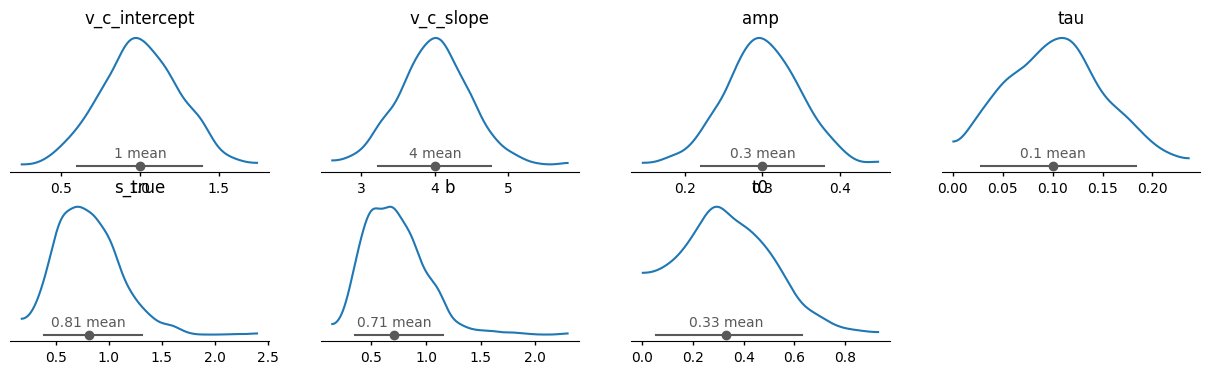

In [103]:
az.plot_dist(dt, group="prior");

### Data

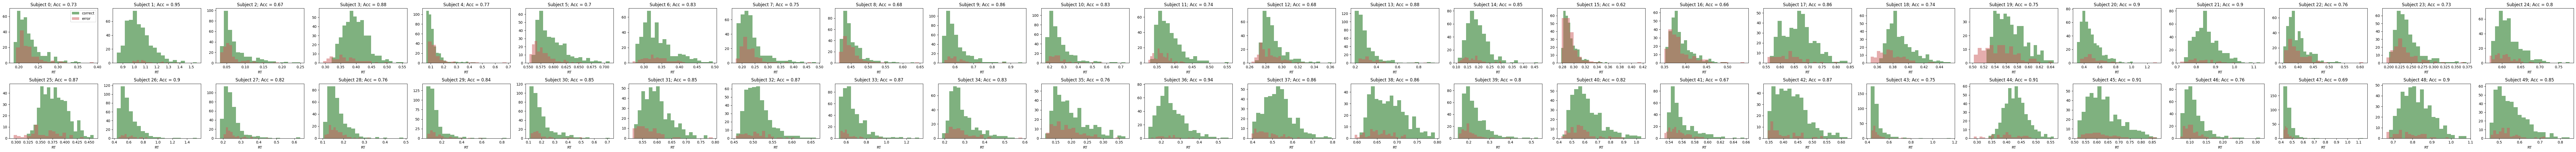

In [104]:
plot_data_hist(dt);

## CRDM (low error)

In [105]:
RESULTS_PATH = "../outputs/crdm/model.num_bins=12/model.num_mid=128/model.recovery_prior.v_c_slope_loc=4.0/model.sampler.dt=0.0005/optimizer=adam_cosine_decay/train_steps=1000000/parameter_recovery_approx.nc"
dt = open_datatree(RESULTS_PATH)
dt.groups, dt.param_names

(('/', '/posterior', '/observed_data', '/constant_data', '/prior'),
 ['v_c_intercept', 'v_c_slope', 'amp', 'tau', 's_true', 'b', 't0'])

In [106]:
dt = fix_chain_draw_dims(dt)

### Parameter Summary

In [107]:
summary = az.summary(dt)
summary

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
v_c_intercept[0],1.24,0.22,0.88,1.60,2982.71,2496.39,1.0,0.00,0.0
v_c_intercept[1],1.13,0.22,0.77,1.49,2134.56,1849.90,1.0,0.00,0.0
v_c_intercept[2],1.02,0.23,0.66,1.37,2030.68,1914.93,1.0,0.00,0.0
v_c_intercept[3],1.08,0.20,0.77,1.40,2317.38,1991.09,1.0,0.00,0.0
v_c_intercept[4],1.04,0.21,0.71,1.37,974.57,945.66,1.0,0.01,0.0
...,...,...,...,...,...,...,...,...,...
t0[45],0.45,0.01,0.44,0.47,1941.17,1977.11,1.0,0.00,0.0
t0[46],0.06,0.00,0.05,0.06,2144.58,2230.78,1.0,0.00,0.0
t0[47],0.41,0.00,0.41,0.41,1305.92,1174.24,1.0,0.00,0.0
t0[48],0.62,0.01,0.59,0.63,1000.19,1227.14,1.0,0.00,0.0


### Convergence Diagnostics

In [108]:
(summary["r_hat"] > 1.01).sum()

np.int64(22)

In [109]:
(summary["r_hat"] > 1.05).sum()

np.int64(16)

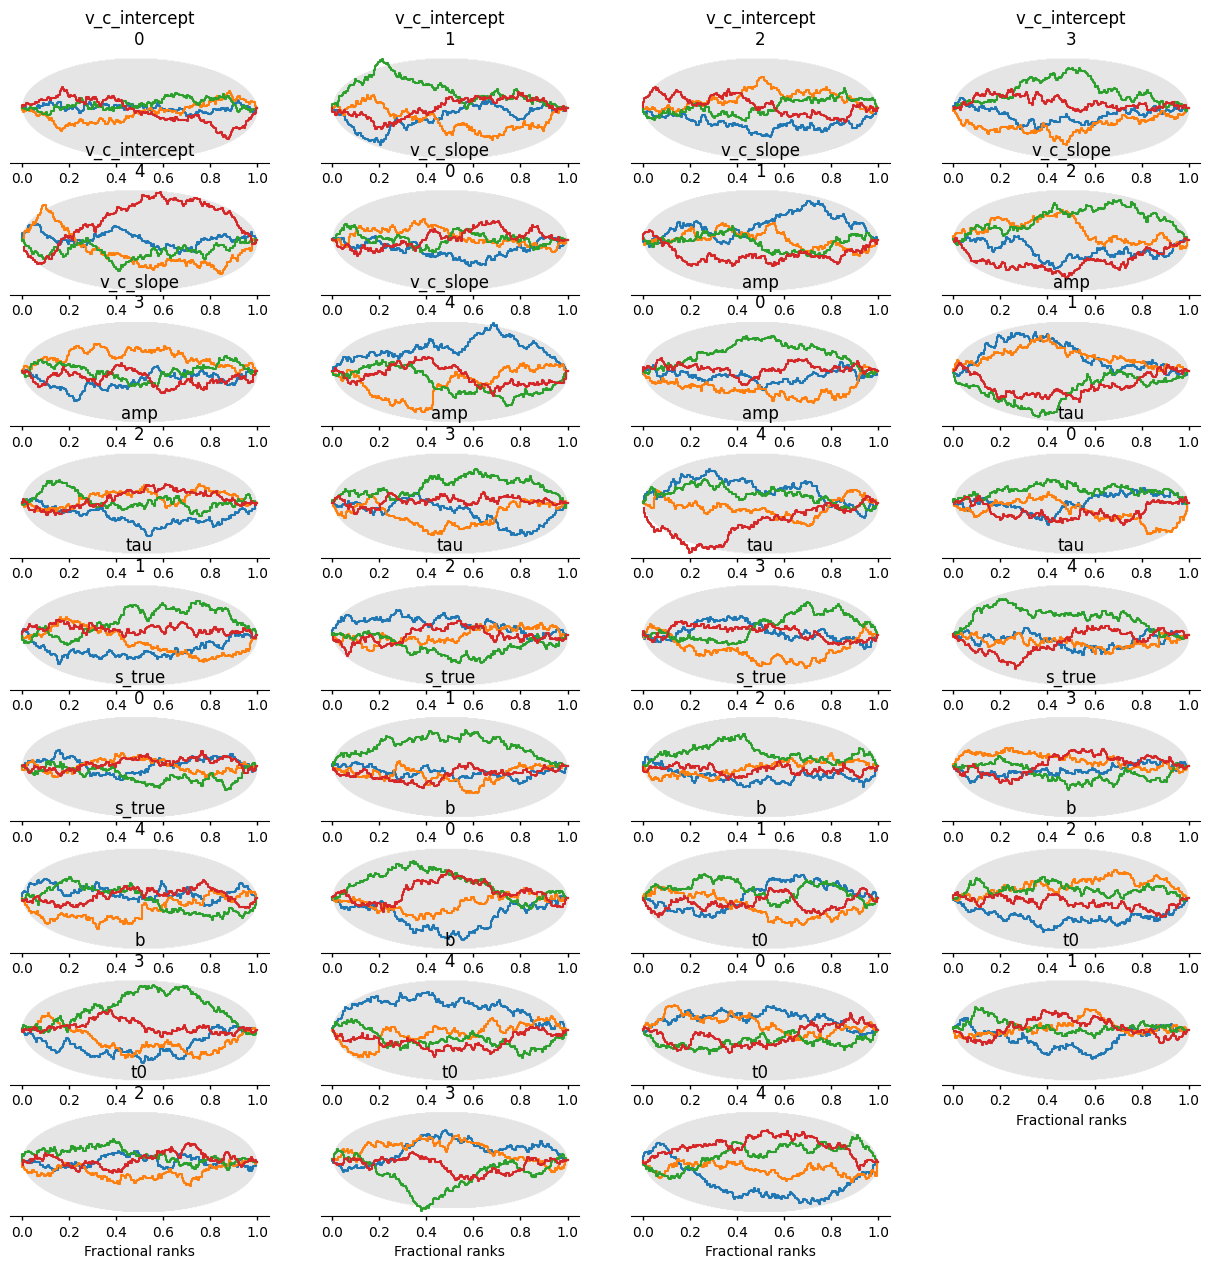

In [110]:
fig = az.plot_rank(dt, coords={"subject": np.arange(5)});

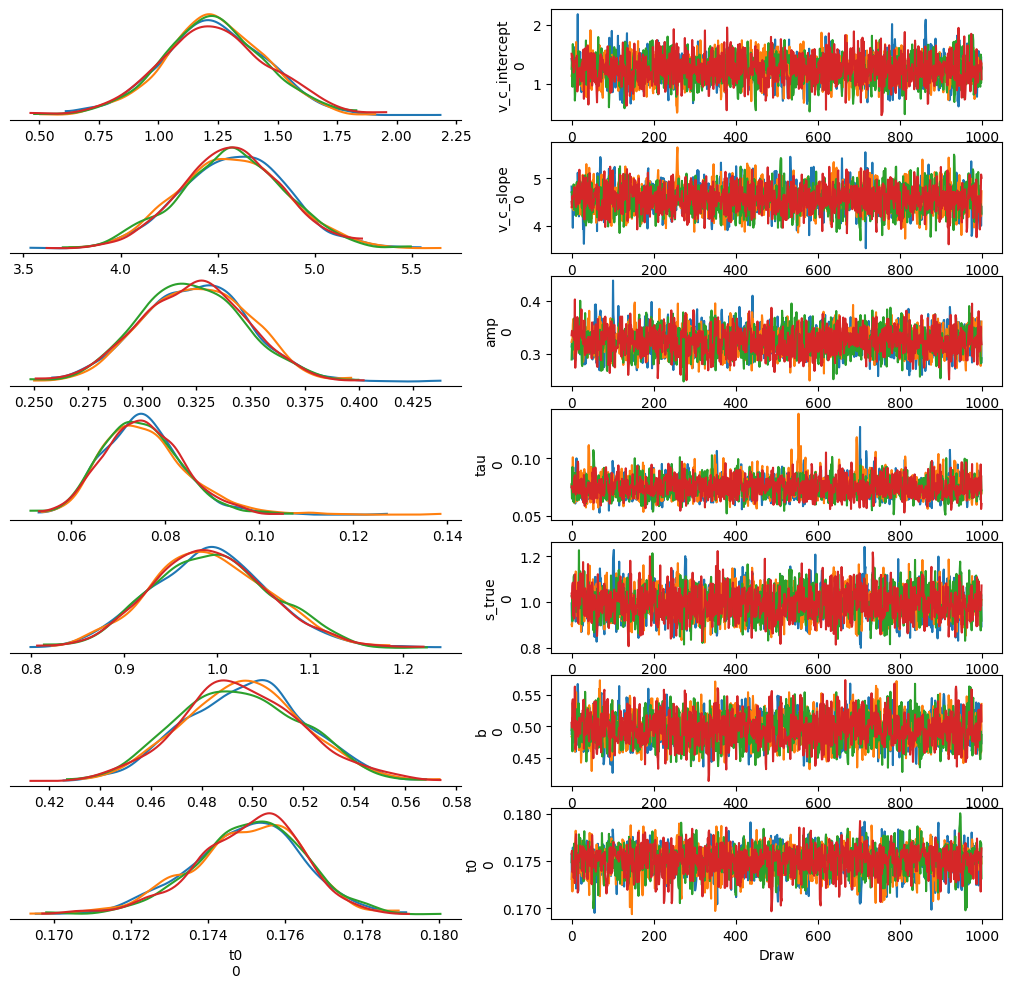

In [111]:
fig = az.plot_trace_dist(dt, coords={"subject": np.arange(1)}, compact=False);

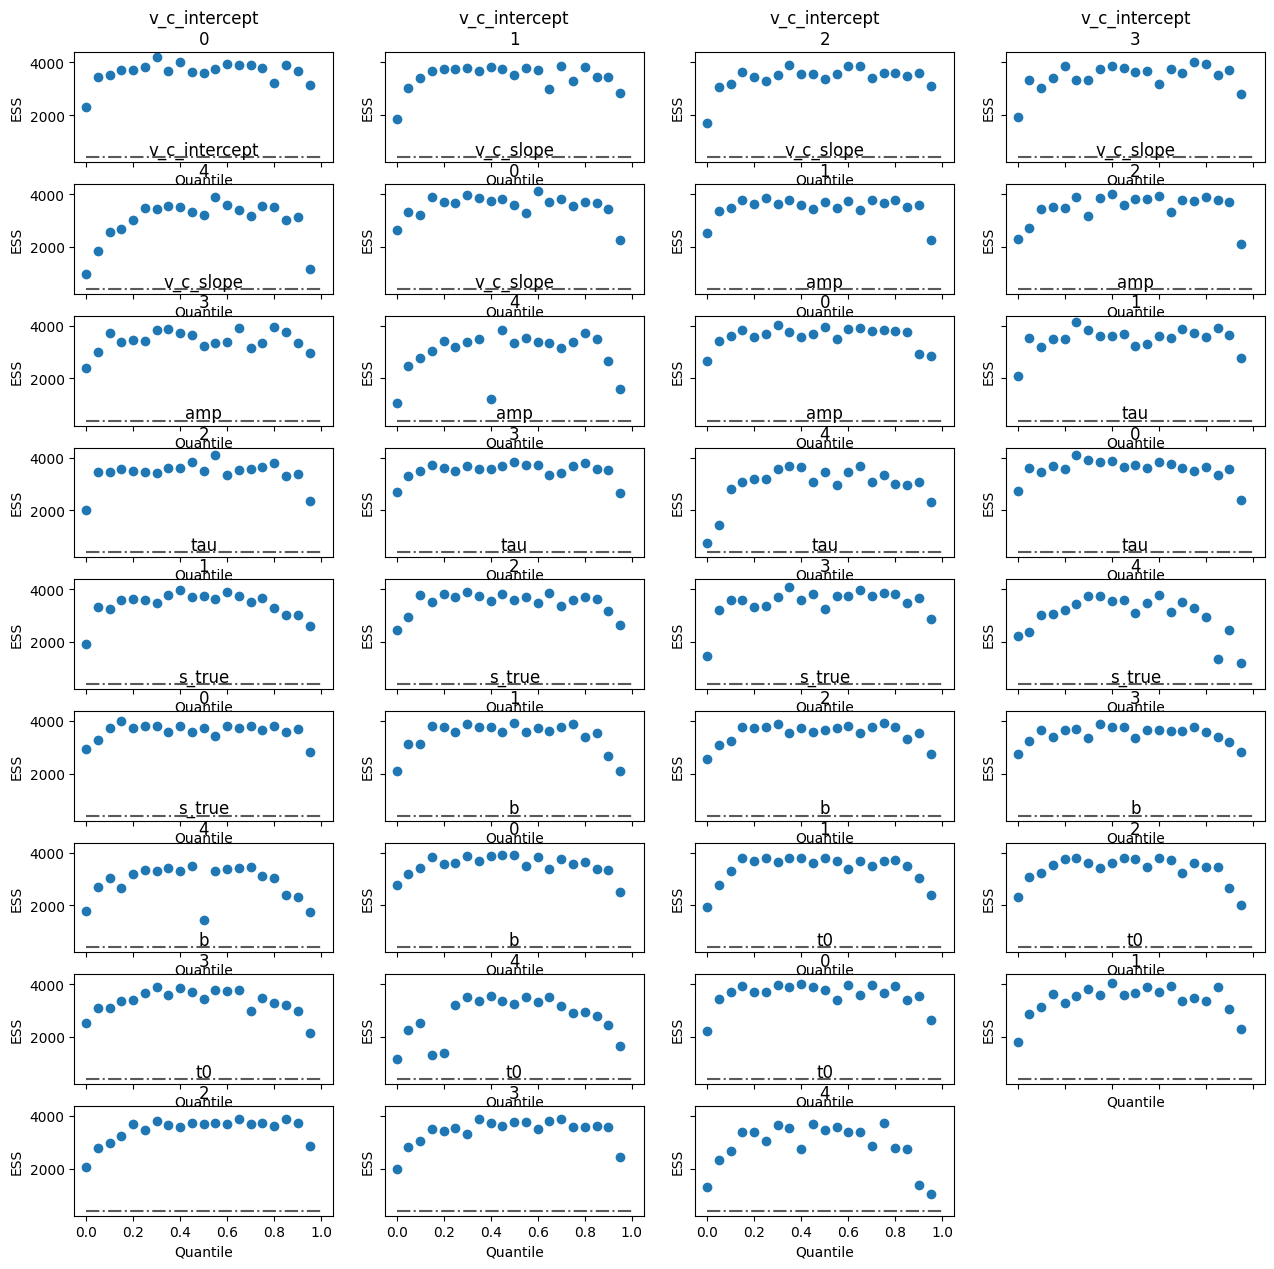

In [112]:
az.plot_ess(dt, coords={"subject": np.arange(5)});

### Parameter Recovery

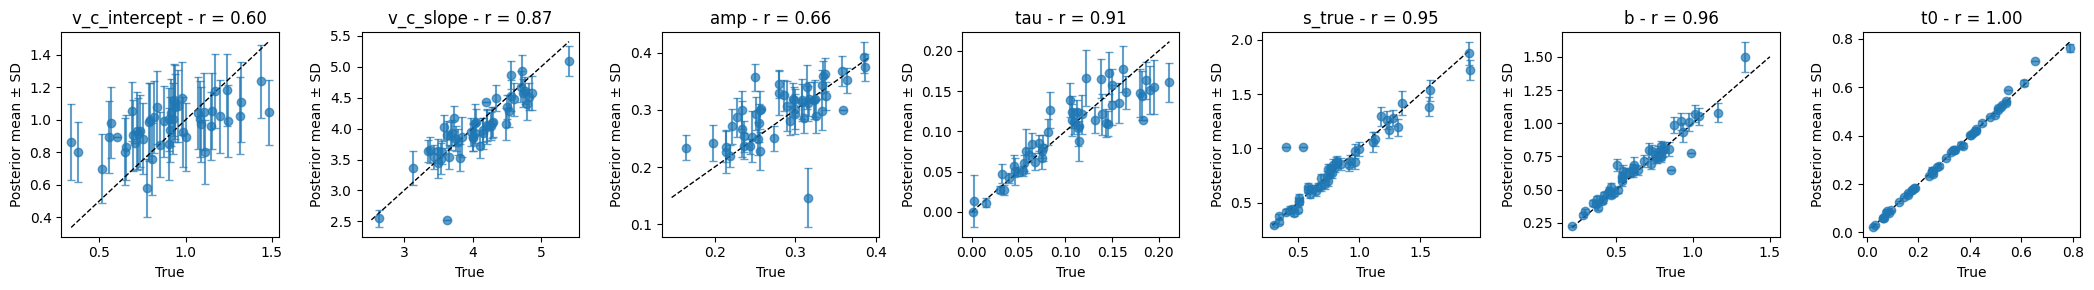

In [113]:
plot_parameter_recovery(dt);

### Posterior Contraction

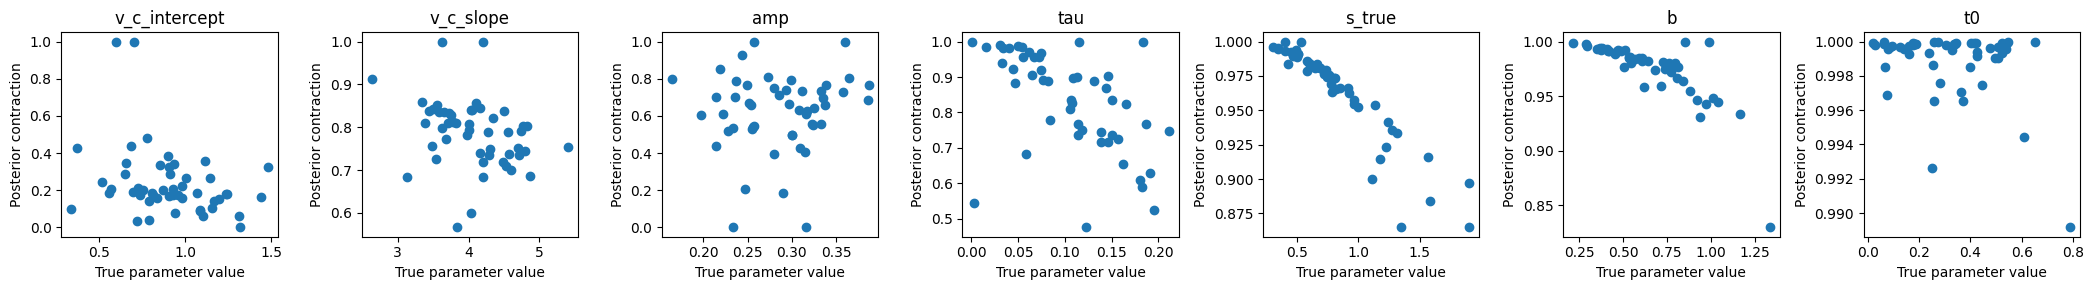

In [114]:
plot_posterior_contraction(dt);

### Prior Samples

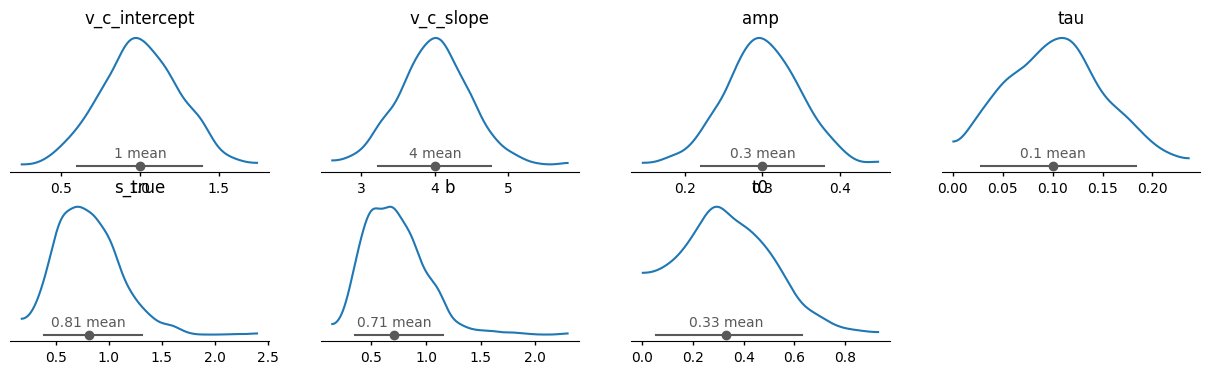

In [115]:
az.plot_dist(dt, group="prior");

### Data

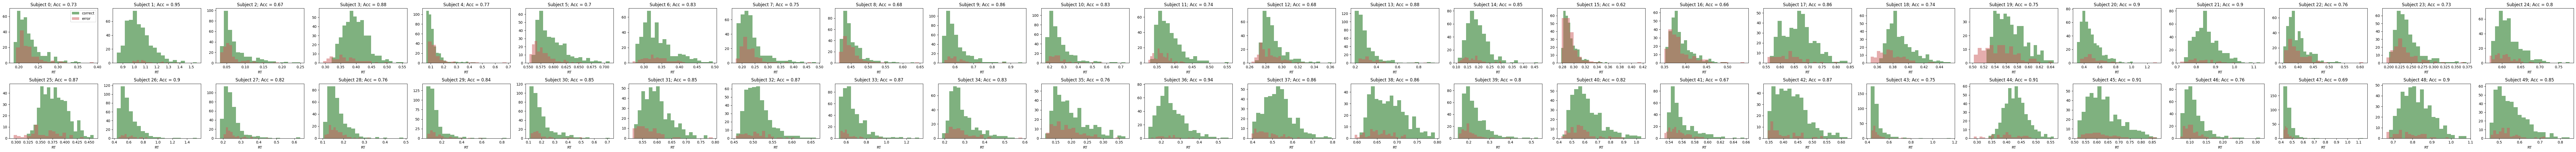

In [116]:
plot_data_hist(dt);